In [1]:
import sys
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', 'shap', '--quiet'])
print('Installation done ✓')

Installation done ✓


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded ✓')

All libraries loaded ✓


In [3]:
DATA_PATH = '../data/'

orders   = pd.read_csv(f'{DATA_PATH}cleaned_orders.csv')
items    = pd.read_csv(f'{DATA_PATH}cleaned_order_items.csv')
payments = pd.read_csv(f'{DATA_PATH}cleaned_order_payments.csv')
reviews  = pd.read_csv(f'{DATA_PATH}cleaned_order_reviews.csv')
customers= pd.read_csv(f'{DATA_PATH}cleaned_customers.csv')
products = pd.read_csv(f'{DATA_PATH}cleaned_products.csv')
trans    = pd.read_csv(f'{DATA_PATH}cleaned_product_category_translation.csv')

# Convert dates
for col in ['order_purchase_timestamp','order_delivered_customer_date',
            'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print('Data loaded ✓')
print(f'Orders: {orders.shape}, Items: {items.shape}, Payments: {payments.shape}')

Data loaded ✓
Orders: (99441, 14), Items: (112650, 7), Payments: (103886, 5)


In [4]:
df = (
    items
    .merge(orders,    on='order_id',   how='left')
    .merge(customers, on='customer_id',how='left')
    .merge(products,  on='product_id', how='left')
    .merge(trans,     on='product_category_name', how='left')
    .merge(reviews[['order_id','review_score']], on='order_id', how='left')
    .merge(payments[['order_id','payment_value','payment_type',
                     'payment_installments']], on='order_id', how='left')
)

print(f'Merged dataset shape: {df.shape}')
df.head(3)

Merged dataset shape: (118310, 37)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_vs_estimate,is_late,order_year_month,order_day_of_week,order_hour,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_score,payment_value,payment_type,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,8.0,False,2017-09,Wednesday,8,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,5.0,72.19,credit_card,2.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,2.0,False,2017-04,Wednesday,10,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,4.0,259.83,credit_card,3.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0,13.0,False,2018-01,Sunday,14,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,5.0,216.87,credit_card,5.0


In [5]:
df['order_month']     = df['order_purchase_timestamp'].dt.month
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['order_hour']      = df['order_purchase_timestamp'].dt.hour
df['order_quarter']   = df['order_purchase_timestamp'].dt.quarter

df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

df['is_late'] = (
    df['order_delivered_customer_date'] >
    df['order_estimated_delivery_date']
).astype(int)

print('Features engineered ✓')
print(df[['order_month','delivery_days','is_late']].describe())

Features engineered ✓
         order_month  delivery_days        is_late
count  118310.000000  115722.000000  118310.000000
mean        6.027580      12.022589       0.076646
std         3.231608       9.454922       0.266030
min         1.000000       0.000000       0.000000
25%         3.000000       6.000000       0.000000
50%         6.000000      10.000000       0.000000
75%         8.000000      15.000000       0.000000
max        12.000000     209.000000       1.000000


In [6]:
features = [
    'freight_value',
    'order_month',
    'order_dayofweek',
    'order_hour',
    'order_quarter',
    'delivery_days',
    'is_late',
    'review_score',
    'payment_installments',
    'product_category_name_english'
]
target = 'payment_value'

ml = df[features + [target]].dropna().copy()

le = LabelEncoder()
ml['product_category_name_english'] = le.fit_transform(
    ml['product_category_name_english'].astype(str)
)

print(f'ML dataset: {ml.shape}')
print(f'Target mean: R$ {ml[target].mean():.2f}')
ml.head(3)

ML dataset: (113209, 11)
Target mean: R$ 171.57


,freight_value,order_month,order_dayofweek,order_hour,order_quarter,delivery_days,is_late,review_score,payment_installments,product_category_name_english,payment_value
0,13.29,9,2,8,3,7.0,0,5.0,2.0,20,72.19
1,19.93,4,2,10,2,16.0,0,4.0,3.0,60,259.83
2,17.87,1,6,14,1,7.0,0,5.0,5.0,39,216.87


In [7]:
X = ml[features]
y = ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (90567, 10)  |  Test: (22642, 10)


In [8]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)

print('RANDOM FOREST')
print(f'  R²   : {rf_r2:.4f}')
print(f'  RMSE : R$ {rf_rmse:.2f}')
print(f'  MAE  : R$ {rf_mae:.2f}')

RANDOM FOREST
  R²   : 0.5091
  RMSE : R$ 188.47
  MAE  : R$ 94.24


In [9]:
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6,
                              learning_rate=0.1, random_state=42,
                              n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_r2   = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)

print('XGBOOST')
print(f'  R²   : {xgb_r2:.4f}')
print(f'  RMSE : R$ {xgb_rmse:.2f}')
print(f'  MAE  : R$ {xgb_mae:.2f}')

XGBOOST
  R²   : 0.5187
  RMSE : R$ 186.63
  MAE  : R$ 91.83


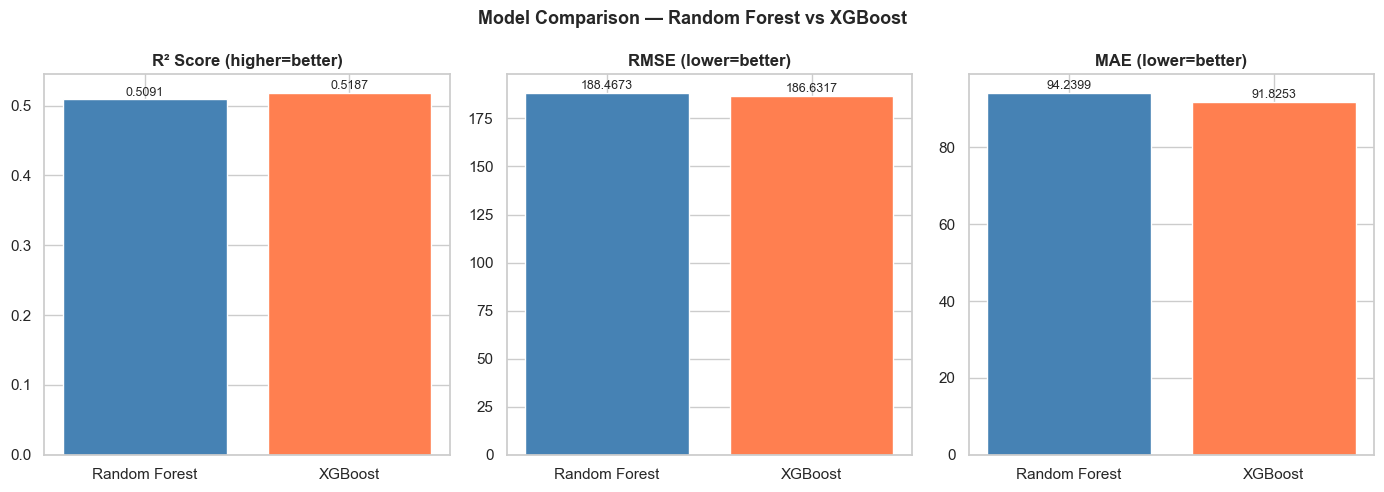

Saved ✓


In [10]:
models = ['Random Forest', 'XGBoost']
r2s    = [rf_r2,   xgb_r2]
rmses  = [rf_rmse, xgb_rmse]
maes   = [rf_mae,  xgb_mae]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['steelblue', 'coral']

for ax, vals, title in zip(axes,
                           [r2s, rmses, maes],
                           ['R² Score (higher=better)',
                            'RMSE (lower=better)',
                            'MAE (lower=better)']):
    bars = ax.bar(models, vals, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() * 1.01,
                f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison — Random Forest vs XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ✓')

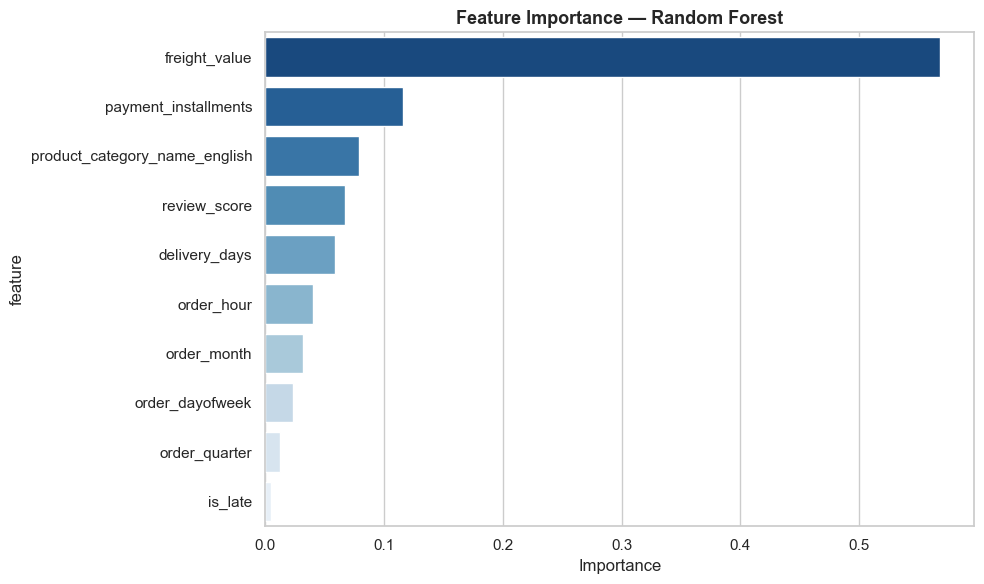

Saved ✓


In [11]:
fi = pd.DataFrame({
    'feature'   : features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='importance', y='feature', palette='Blues_r')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ✓')

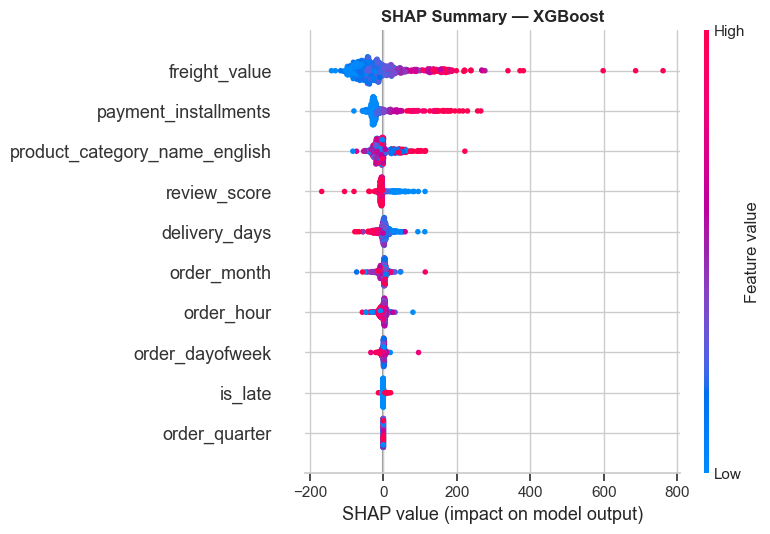

Saved ✓


In [12]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:500],
                  feature_names=features, show=False)
plt.title('SHAP Summary — XGBoost', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ✓')

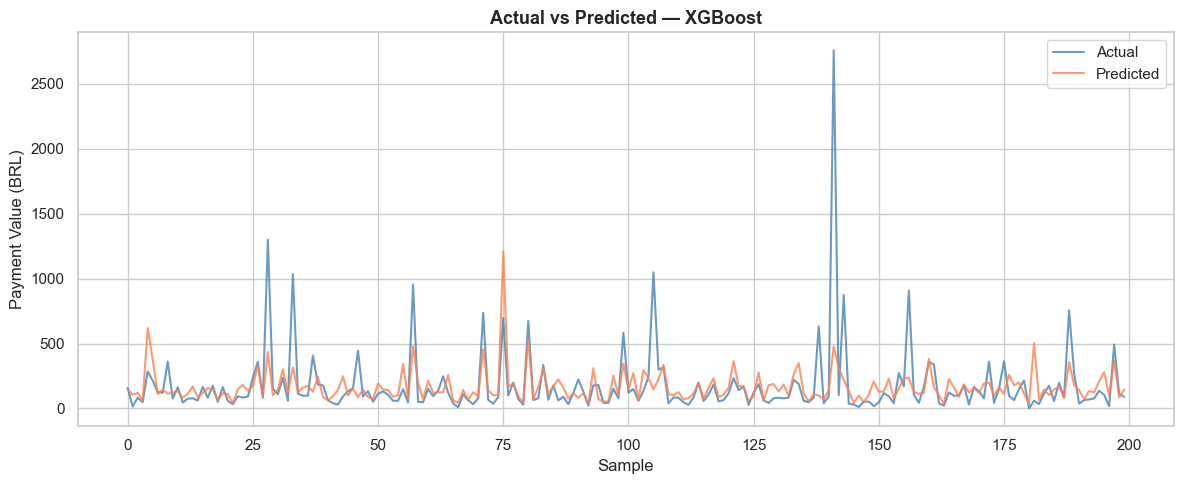

Saved ✓


In [13]:
best_pred = xgb_pred if xgb_r2 >= rf_r2 else rf_pred
best_name = 'XGBoost' if xgb_r2 >= rf_r2 else 'Random Forest'

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200],  label='Actual',    color='steelblue', alpha=0.8)
plt.plot(best_pred[:200],      label='Predicted', color='coral',     alpha=0.8)
plt.title(f'Actual vs Predicted — {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Sample')
plt.ylabel('Payment Value (BRL)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ✓')

In [14]:
print('='*45)
print('   FINAL MODEL RESULTS')
print('='*45)
print(f'  Random Forest  R²: {rf_r2:.4f}  RMSE: {rf_rmse:.2f}')
print(f'  XGBoost        R²: {xgb_r2:.4f}  RMSE: {xgb_rmse:.2f}')
print(f'  Best Model: {"XGBoost" if xgb_r2 >= rf_r2 else "Random Forest"}')
print('='*45)

results = pd.DataFrame({
    'Model': ['Random Forest','XGBoost'],
    'R2'   : [round(rf_r2,4), round(xgb_r2,4)],
    'RMSE' : [round(rf_rmse,2), round(xgb_rmse,2)],
    'MAE'  : [round(rf_mae,2), round(xgb_mae,2)]
})
results.to_csv('../outputs/ml_results.csv', index=False)
print('Results saved to outputs/ml_results.csv ✓')

   FINAL MODEL RESULTS
  Random Forest  R²: 0.5091  RMSE: 188.47
  XGBoost        R²: 0.5187  RMSE: 186.63
  Best Model: XGBoost
Results saved to outputs/ml_results.csv ✓


In [15]:
df.columns.tolist() 

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'delivery_vs_estimate',
 'is_late',
 'order_year_month',
 'order_day_of_week',
 'order_hour',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'review_score',
 'payment_value',
 'payment_type',
 'payment_installments',
 'order_month',
 'order_dayofweek',
 'order_quarter']

In [16]:
# ============================================================
# SECTION 7 — Binary Classification + DPS + SHAP + Revenue
# Add these cells at the bottom of 06_ml_regression_shap.ipynb
# ============================================================

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── STEP 1: Binary Target ────────────────────────────────────
df_model = df.copy()

df_model['low_review_risk'] = (df_model['review_score'] <= 2).astype(int)

print("Class distribution:")
print(df_model['low_review_risk'].value_counts())
print(f"Positive class rate: {df_model['low_review_risk'].mean():.2%}")

Class distribution:
low_review_risk
0    99368
1    18942
Name: count, dtype: int64
Positive class rate: 16.01%


In [17]:
# ── STEP 2: Delivery Performance Score (DPS) ─────────────────
# You already have delivery_days and delivery_vs_estimate — use them directly

# Component A: Late delivery penalty (only penalise positive delay)
# delivery_vs_estimate = actual_days - estimated_days (already in your df)
df_model['delay_penalty'] = df_model['delivery_vs_estimate'].clip(lower=0)

# Component B: Freight cost ratio
df_model['freight_ratio'] = df_model['freight_value'] / (df_model['payment_value'] + 1e-9)

# Component C: Total delivery window (delivery_days = purchase to delivery)
# already exists in your df as delivery_days

# Normalise each to 0–1 (higher = worse delivery experience)
def minmax_norm(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

df_model['dps_delay']   = minmax_norm(df_model['delay_penalty'])
df_model['dps_freight'] = minmax_norm(df_model['freight_ratio'])
df_model['dps_window']  = minmax_norm(df_model['delivery_days'])

# DPS composite (weighted)
df_model['DPS'] = (
    0.5 * df_model['dps_delay'] +
    0.3 * df_model['dps_freight'] +
    0.2 * df_model['dps_window']
)

print("DPS summary:")
print(df_model['DPS'].describe())

DPS summary:
count    115719.000000
mean          0.051979
std           0.025490
min           0.000957
25%           0.034348
50%           0.049154
75%           0.064918
max           0.502871
Name: DPS, dtype: float64


In [18]:
# ── STEP 3: Feature Matrix ────────────────────────────────────
top_cats = df_model['product_category_name_english'].value_counts().nlargest(15).index
df_model['category_grouped'] = df_model['product_category_name_english'].where(
    df_model['product_category_name_english'].isin(top_cats), other='other'
)
cat_dummies = pd.get_dummies(df_model['category_grouped'], prefix='cat', drop_first=True)

feature_cols = [
    'DPS',
    'delivery_vs_estimate',   # raw delay (signed)
    'delivery_days',           # total window
    'freight_ratio',
    'freight_value',
    'payment_value',
    'price',
    'is_late',                 # binary flag already in your df
    'product_photos_qty',
    'payment_installments',
    'order_quarter'
]

X = pd.concat([
    df_model[feature_cols].reset_index(drop=True),
    cat_dummies.reset_index(drop=True)
], axis=1)

y = df_model['low_review_risk'].reset_index(drop=True)

# Remove rows with NaN (undelivered/incomplete orders)
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

print(f"Final dataset: {X.shape[0]:,} rows, {X.shape[1]} features")
print(f"Low-review-risk orders: {y.sum():,} ({y.mean():.2%})")

Final dataset: 115,719 rows, 26 features
Low-review-risk orders: 17,017 (14.71%)


In [19]:
# ── STEP 4: Train/Test Split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── STEP 5: XGBoost Classifier ───────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos:.2f}")

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42
)
xgb_clf.fit(X_train, y_train)
print("XGBoost training complete.")

Class imbalance ratio (scale_pos_weight): 5.80
XGBoost training complete.


── XGBoost Classification Report ──
                     precision    recall  f1-score   support

  Normal Review (0)       0.92      0.83      0.88     19741
Low Review Risk (1)       0.38      0.60      0.47      3403

           accuracy                           0.80     23144
          macro avg       0.65      0.72      0.67     23144
       weighted avg       0.84      0.80      0.82     23144

AUC-ROC: 0.7753


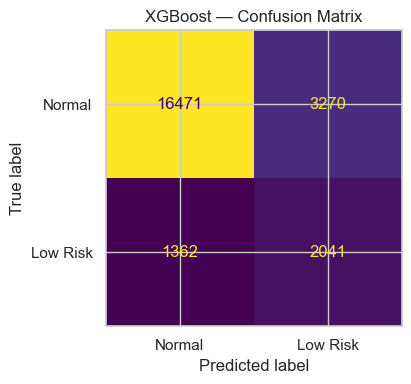

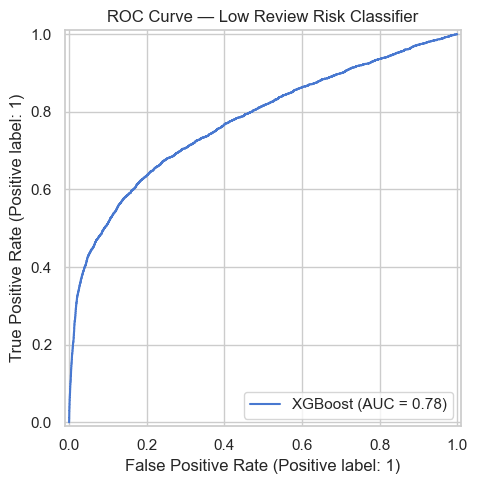

In [20]:
# ── STEP 6: Evaluation ───────────────────────────────────────
y_pred  = xgb_clf.predict(X_test)
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

print("── XGBoost Classification Report ──")
print(classification_report(y_test, y_pred,
      target_names=['Normal Review (0)', 'Low Review Risk (1)']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax,
    display_labels=['Normal', 'Low Risk'], colorbar=False
)
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png", dpi=150)
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name="XGBoost")
ax.set_title("ROC Curve — Low Review Risk Classifier")
plt.tight_layout()
plt.savefig("roc_curve_xgb.png", dpi=150)
plt.show()

Running SHAP (1–2 minutes)...


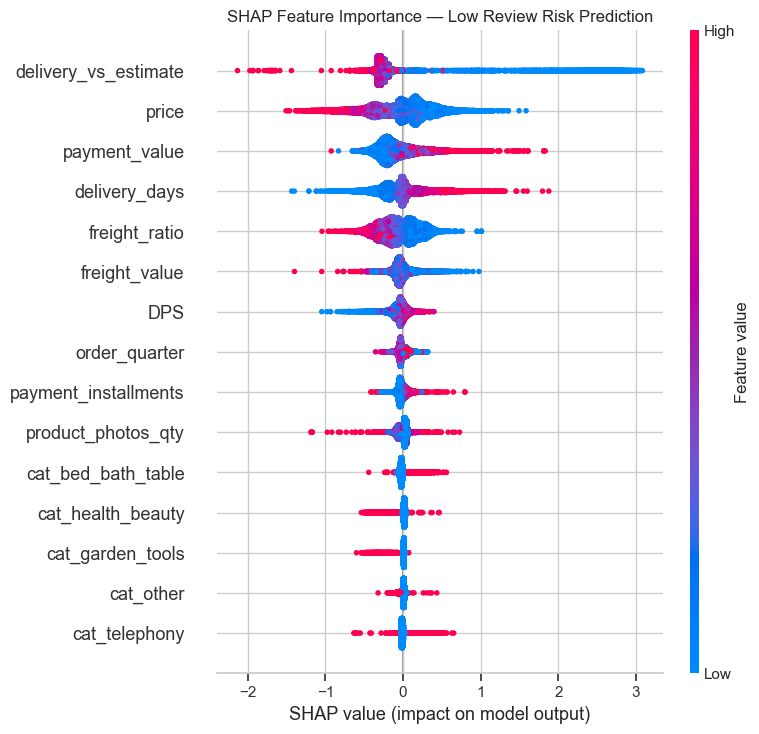

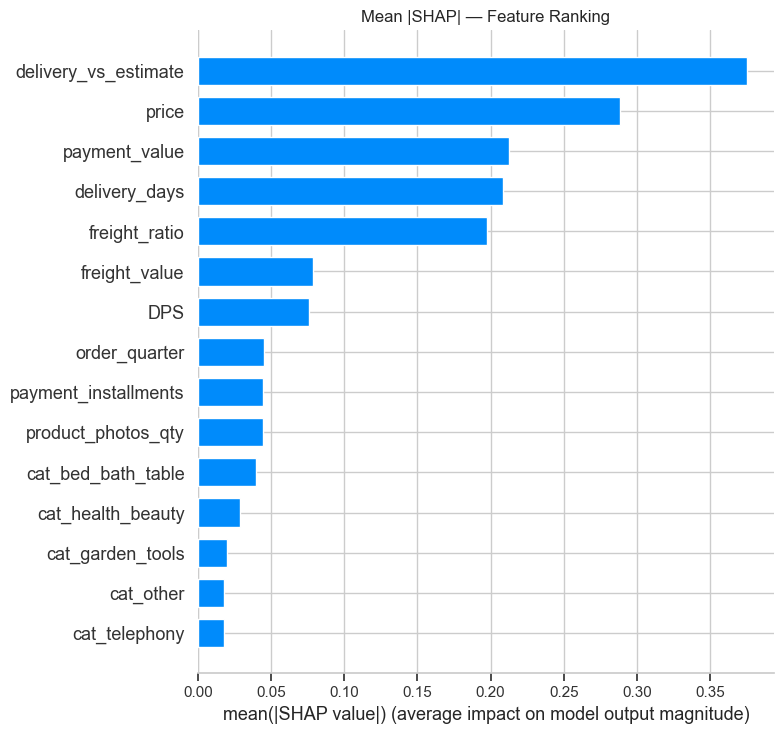

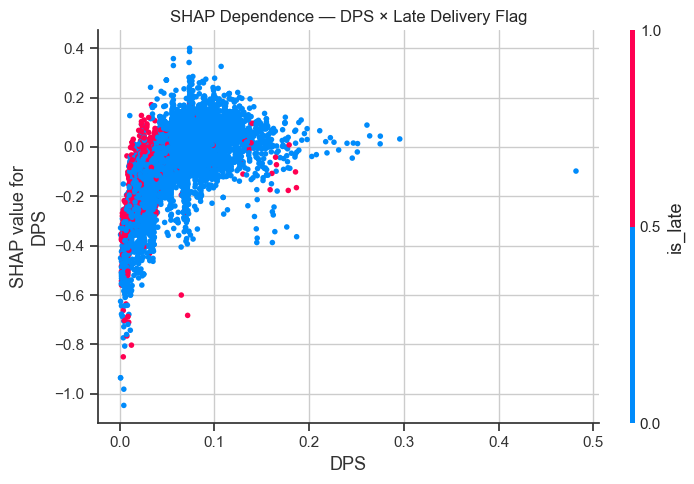

In [21]:
# ── STEP 7: SHAP ─────────────────────────────────────────────
print("Running SHAP (1–2 minutes)...")
explainer = shap.TreeExplainer(xgb_clf)
shap_vals = explainer.shap_values(X_test)

# Beeswarm — Figure 1 in paper
shap.summary_plot(shap_vals, X_test, plot_type="dot",
                  max_display=15, show=False)
plt.title("SHAP Feature Importance — Low Review Risk Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

# Bar plot
shap.summary_plot(shap_vals, X_test, plot_type="bar",
                  max_display=15, show=False)
plt.title("Mean |SHAP| — Feature Ranking")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

# Dependence plot: DPS × is_late
shap.dependence_plot("DPS", shap_vals, X_test,
                     interaction_index="is_late", show=False)
plt.title("SHAP Dependence — DPS × Late Delivery Flag")
plt.tight_layout()
plt.savefig("shap_dependence_dps.png", dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── STEP 8: Revenue Impact ────────────────────────────────────
df_impact = df_model[mask].copy().reset_index(drop=True)
df_impact['predicted_risk']  = xgb_clf.predict(X)
df_impact['predicted_proba'] = xgb_clf.predict_proba(X)[:, 1]

# Revenue at risk = order value × predicted probability × churn assumption × repeat order multiplier
CHURN_RATE     = 0.30   # 30% of low-review customers don't reorder (conservative; cite in paper)
REPEAT_ORDERS  = 1.8    # avg repeat orders on Olist (cite platform stats)

df_impact['revenue_at_risk'] = (
    df_impact['payment_value'] *
    df_impact['predicted_proba'] *
    CHURN_RATE *
    REPEAT_ORDERS
)

high_risk = df_impact[df_impact['predicted_risk'] == 1]

print("── Revenue Impact Summary ──")
print(f"High-risk orders identified:       {len(high_risk):,}")
print(f"Total revenue at risk (R$):        {high_risk['revenue_at_risk'].sum():,.0f}")
print(f"Avg revenue at risk per order (R$):{high_risk['revenue_at_risk'].mean():.2f}")

# Category breakdown → becomes Table 3 in your paper
cat_impact = (
    high_risk.groupby('category_grouped')['revenue_at_risk']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .round(2)
)
cat_impact.columns = ['Total Revenue at Risk (R$)', 'Avg per Order (R$)', 'High-Risk Orders']
print("\n── Revenue at Risk by Category (Top 10) ──")
print(cat_impact.head(10).to_string())
cat_impact.to_csv("revenue_impact_by_category.csv", index=True)

print("\n✅ All outputs saved. Run df_impact.head() to verify.")

── Revenue Impact Summary ──
High-risk orders identified:       26,339
Total revenue at risk (R$):        2,541,781
Avg revenue at risk per order (R$):96.50

── Revenue at Risk by Category (Top 10) ──
                       Total Revenue at Risk (R$)  Avg per Order (R$)  High-Risk Orders
category_grouped                                                                       
other                                   648041.79              126.72              5114
computers_accessories                   309912.51              134.28              2308
bed_bath_table                          307877.09               76.24              4038
furniture_decor                         264795.39               87.05              3042
housewares                              152403.59               98.20              1552
sports_leisure                          149498.65               86.57              1727
watches_gifts                           123863.95               97.76              1267
health_

In [23]:
# Cell A — Classification metrics
print(classification_report(y_test, y_pred,
      target_names=['Normal Review (0)', 'Low Review Risk (1)']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

                     precision    recall  f1-score   support

  Normal Review (0)       0.92      0.83      0.88     19741
Low Review Risk (1)       0.38      0.60      0.47      3403

           accuracy                           0.80     23144
          macro avg       0.65      0.72      0.67     23144
       weighted avg       0.84      0.80      0.82     23144

AUC-ROC: 0.7753


In [24]:
# Cell B — DPS validation (proves your novel feature adds value)
import pandas as pd

# SHAP mean absolute values per feature
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance.head(15).to_string())

                 feature  mean_abs_shap
1   delivery_vs_estimate       0.374927
6                  price       0.288770
5          payment_value       0.212430
2          delivery_days       0.208509
3          freight_ratio       0.197603
4          freight_value       0.078699
0                    DPS       0.075800
10         order_quarter       0.045371
9   payment_installments       0.044484
8     product_photos_qty       0.044350
12    cat_bed_bath_table       0.039810
18     cat_health_beauty       0.028849
17      cat_garden_tools       0.019837
20             cat_other       0.017942
23         cat_telephony       0.017805
